In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)



In [13]:

# Phase 1: Exploratory Data Analysis (EDA)

# 1. Dataset overview & Data type inspection
print("Loading dataset...")
df = pd.read_csv('/employee_burnout_dataset_1000_records.csv')
print("\n--- Dataset Info ---")
display(df.info())




Loading dataset...

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            1000 non-null   int64  
 1   age                    1000 non-null   int64  
 2   years_experience       1000 non-null   int64  
 3   weekly_work_hours      1000 non-null   int64  
 4   meetings_per_week      1000 non-null   int64  
 5   emails_sent_per_day    1000 non-null   int64  
 6   projects_handled       1000 non-null   int64  
 7   remote_days_per_month  1000 non-null   int64  
 8   sleep_hours            1000 non-null   float64
 9   stress_level           1000 non-null   int64  
 10  exercise_hours_week    1000 non-null   float64
 11  sick_leaves_year       1000 non-null   int64  
 12  productivity_score     1000 non-null   int64  
 13  burnout_risk_score     1000 non-null   float64
dtypes: float64(3), i

None

In [14]:
print("\n--- First 5 Rows ---")
display(df.head())




--- First 5 Rows ---


,employee_id,age,years_experience,weekly_work_hours,meetings_per_week,emails_sent_per_day,projects_handled,remote_days_per_month,sleep_hours,stress_level,exercise_hours_week,sick_leaves_year,productivity_score,burnout_risk_score
0,1,50,29,66,6,148,7,9,6.3,9,2.6,1,80,9.57
1,2,36,28,51,18,195,3,6,7.9,2,1.6,13,77,0.00
2,3,29,28,34,6,194,3,7,7.0,7,3.6,1,65,0.00
3,4,42,29,31,5,13,1,5,7.3,6,2.5,9,89,0.00
4,5,40,15,56,23,144,3,0,9.0,5,6.8,10,41,9.60


In [17]:
# 2. Missing value analysis
print("\n--- Missing Values ---")
print(df.isnull().sum())
# Note: The dataset has 0 missing values based on inspection.

# 3. Statistical summary
print("\n--- Statistical Summary ---")
display(df.describe())




--- Missing Values ---
employee_id              0
age                      0
years_experience         0
weekly_work_hours        0
meetings_per_week        0
emails_sent_per_day      0
projects_handled         0
remote_days_per_month    0
sleep_hours              0
stress_level             0
exercise_hours_week      0
sick_leaves_year         0
productivity_score       0
burnout_risk_score       0
dtype: int64

--- Statistical Summary ---


,employee_id,age,years_experience,weekly_work_hours,meetings_per_week,emails_sent_per_day,projects_handled,remote_days_per_month,sleep_hours,stress_level,exercise_hours_week,sick_leaves_year,productivity_score,burnout_risk_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,40.947000,17.201000,52.457000,13.149000,108.796000,5.065000,9.593000,6.484000,5.601000,5.126200,7.336000,69.908000,6.565830
std,288.819436,11.160858,10.200424,12.906538,6.695942,54.945804,2.535982,5.748425,1.467357,3.009461,2.913424,4.270989,17.345559,9.458972
min,1.000000,22.000000,0.000000,30.000000,2.000000,10.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000,40.000000,0.000000
25%,250.750000,31.000000,8.000000,41.000000,7.000000,63.000000,3.000000,5.000000,5.200000,3.000000,2.600000,4.000000,55.000000,0.000000
50%,500.500000,42.000000,17.000000,52.000000,13.000000,111.000000,5.000000,10.000000,6.500000,6.000000,5.200000,7.000000,70.000000,0.145000
75%,750.250000,50.000000,26.000000,64.000000,19.000000,157.000000,7.000000,15.000000,7.700000,8.000000,7.700000,11.000000,85.000000,11.425000
max,1000.000000,59.000000,34.000000,74.000000,24.000000,199.000000,9.000000,19.000000,9.000000,10.000000,10.000000,14.000000,99.000000,51.780000


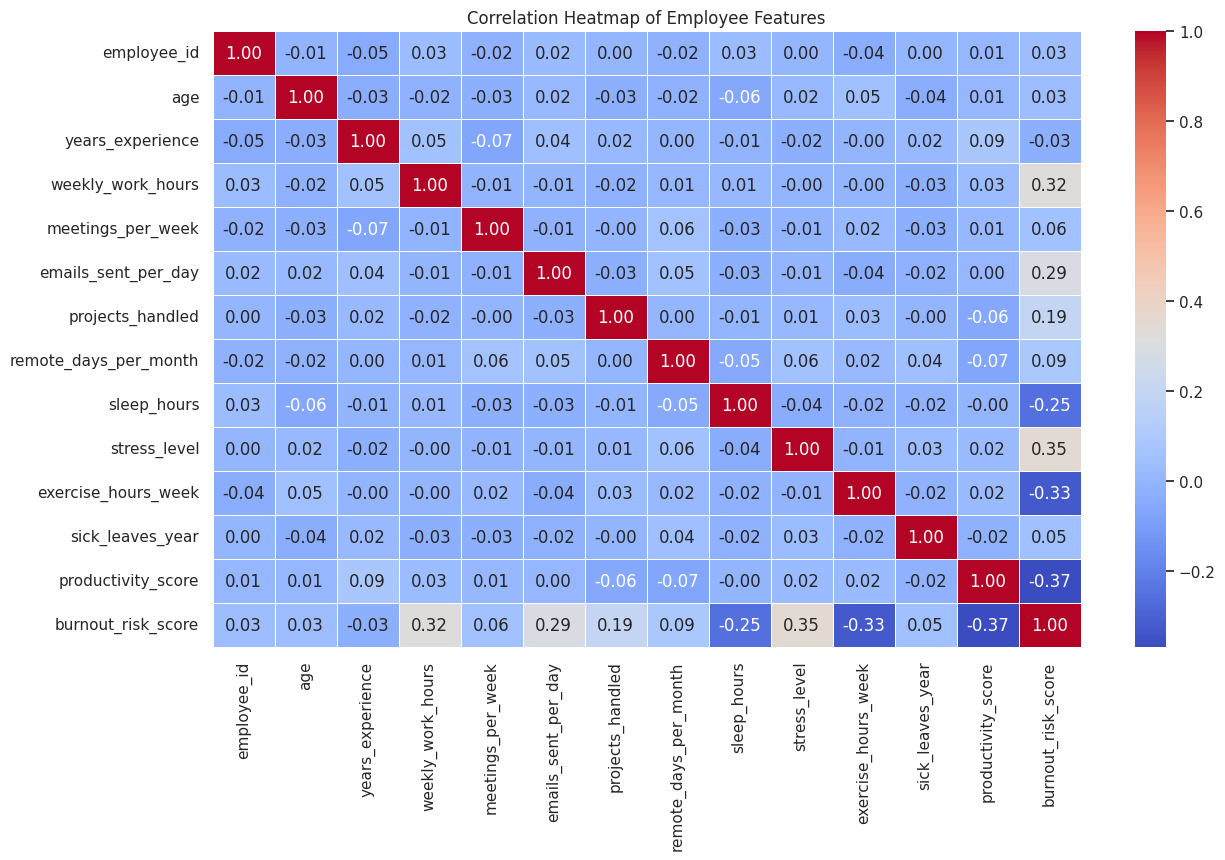

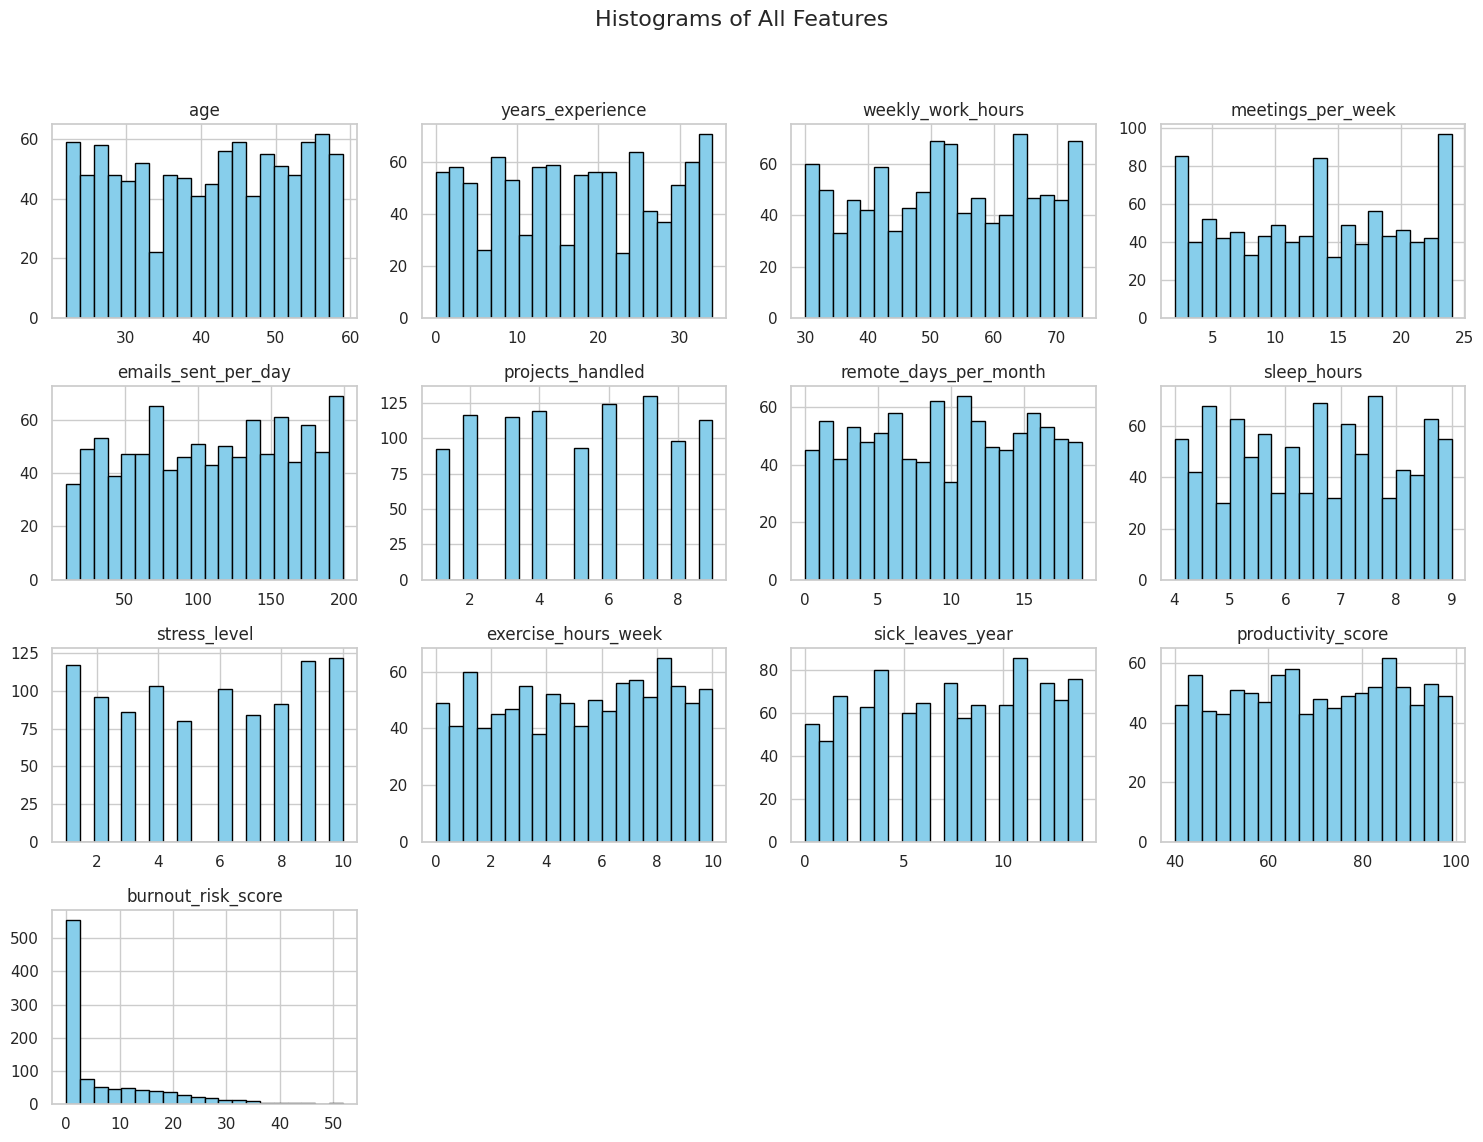

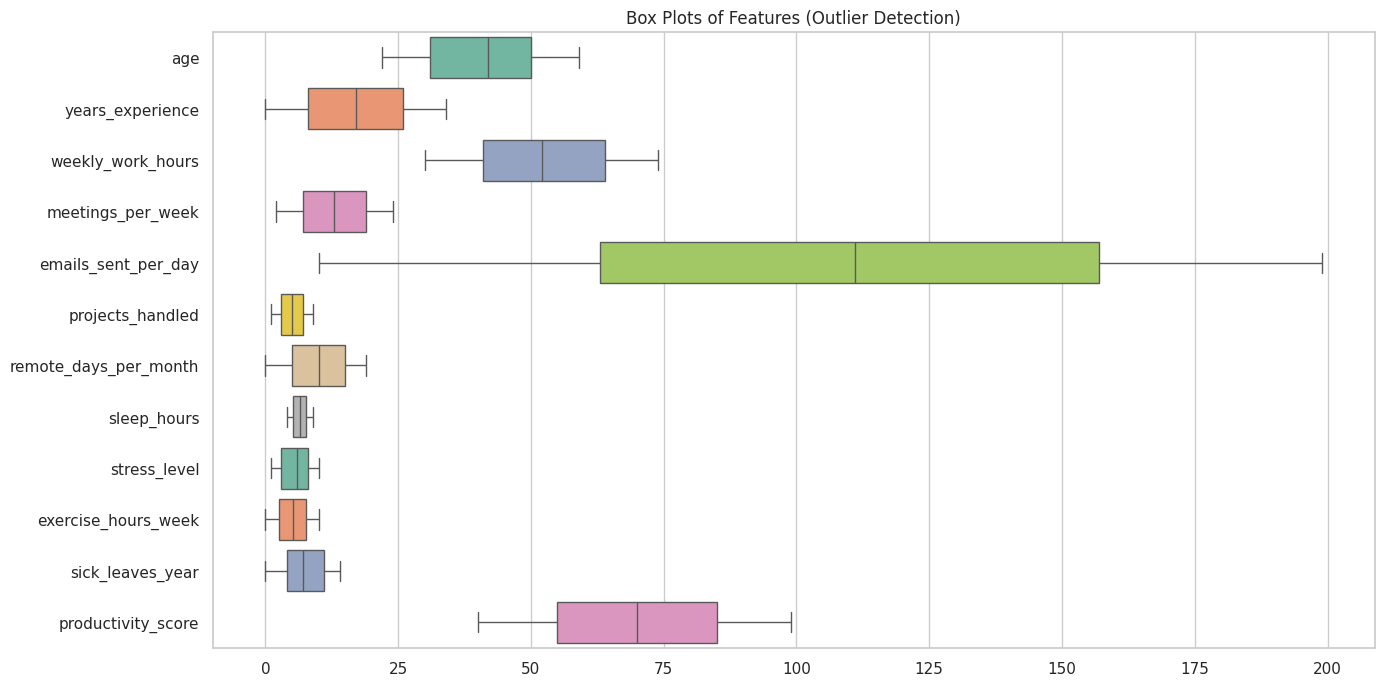

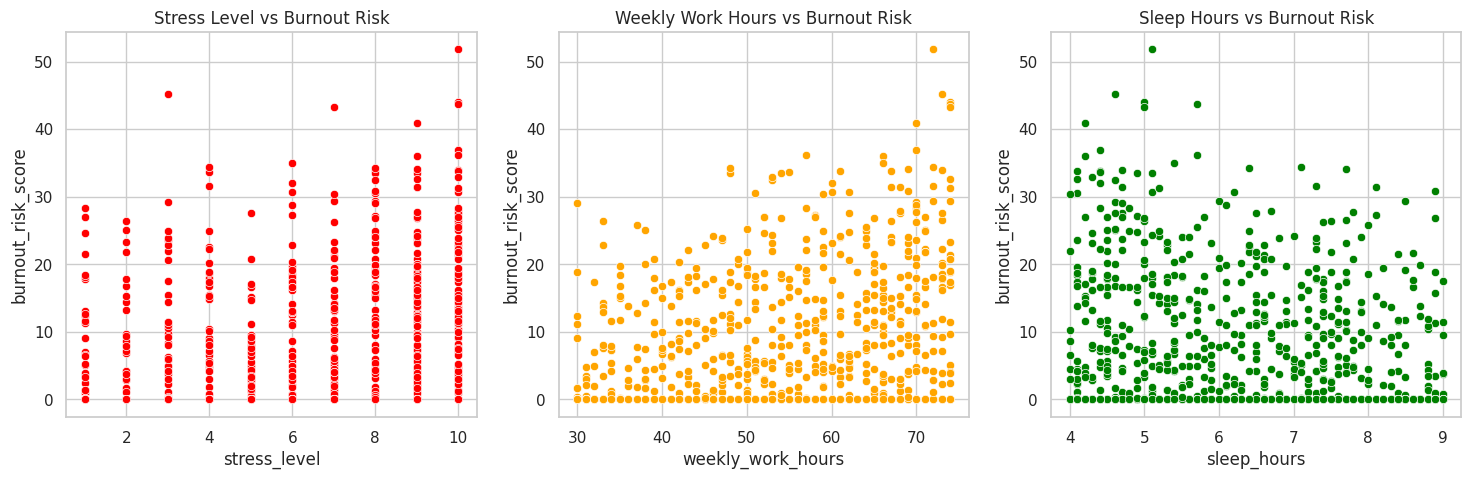

In [18]:
# 4. Visualizations
# a) Correlation Heatmap
plt.figure(figsize=(14, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Employee Features')
plt.show()

# b) Distribution Analysis & Histograms
df.drop('employee_id', axis=1).hist(bins=20, figsize=(15, 12), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of All Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# c) Box Plots for Outlier Identification
plt.figure(figsize=(15, 8))
sns.boxplot(data=df.drop(['employee_id', 'burnout_risk_score'], axis=1), orient="h", palette="Set2")
plt.title('Box Plots of Features (Outlier Detection)')
plt.show()

# d) Scatter Plots (Target vs Key Features)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x='stress_level', y='burnout_risk_score', data=df, ax=axes[0], color='red')
axes[0].set_title('Stress Level vs Burnout Risk')

sns.scatterplot(x='weekly_work_hours', y='burnout_risk_score', data=df, ax=axes[1], color='orange')
axes[1].set_title('Weekly Work Hours vs Burnout Risk')

sns.scatterplot(x='sleep_hours', y='burnout_risk_score', data=df, ax=axes[2], color='green')
axes[2].set_title('Sleep Hours vs Burnout Risk')
plt.show()


In [19]:
# Phase 2: Data Preprocessing

# 1. Remove unnecessary columns
df_processed = df.drop(['employee_id'], axis=1)

# 2. Feature Selection
X = df_processed.drop('burnout_risk_score', axis=1)
y = df_processed['burnout_risk_score']

# 3. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling
# Scaling is crucial for Linear Regression to interpret feature importance via coefficients
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to dataframe for easier coefficient mapping later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n--- Preprocessing Completed ---")
print(f"Training shape: {X_train_scaled.shape}, Testing shape: {X_test_scaled.shape}")




--- Preprocessing Completed ---
Training shape: (800, 12), Testing shape: (200, 12)


In [27]:
# Phase 3: Model Development

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Generate Predictions
y_pred_train = lr_model.predict(X_train_scaled)
y_pred_test = lr_model.predict(X_test_scaled)

# Interpret Regression Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Model Coefficients ---")
print("Positive coefficients increase burnout risk; negative decrease it.")
display(coefficients)




--- Model Coefficients ---
Positive coefficients increase burnout risk; negative decrease it.


,Feature,Coefficient
8,stress_level,3.321535
2,weekly_work_hours,3.304417
4,emails_sent_per_day,2.693379
5,projects_handled,1.788788
3,meetings_per_week,0.596801
10,sick_leaves_year,0.453520
0,age,0.348420
6,remote_days_per_month,0.208028
1,years_experience,-0.044382
7,sleep_hours,-2.284135


In [21]:

# Phase 4: Model Evaluation

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("\n--- Model Evaluation Metrics (Test Set) ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")




--- Model Evaluation Metrics (Test Set) ---
Mean Absolute Error (MAE): 4.65
Mean Squared Error (MSE): 34.02
Root Mean Squared Error (RMSE): 5.83
R² Score: 0.6147


In [32]:
predictions_df = pd.DataFrame({'Actual Burnout Risk': y_test, 'Predicted Burnout Risk': y_pred_test})
display(predictions_df)

,Actual Burnout Risk,Predicted Burnout Risk
521,4.39,12.145768
737,0.00,-2.251263
740,0.28,6.384737
660,0.00,6.713352
411,10.87,13.424267
...,...,...
408,0.00,-3.795214
332,33.63,23.189193
208,0.00,1.883432
613,0.00,1.609176


In [33]:
predictions_df = pd.DataFrame({'Actual Burnout Risk': y_train, 'Predicted Burnout Risk': y_pred_train})
display(predictions_df)

,Actual Burnout Risk,Predicted Burnout Risk
29,0.00,-2.370526
535,0.00,7.796367
695,0.00,8.425886
557,0.00,7.119849
836,0.00,-0.816036
...,...,...
106,0.00,6.466177
270,2.36,7.880938
860,29.12,20.015972
435,20.85,19.499709
